# Adapter Performance Analysis: Negative Shifts and Training Accuracy

This notebook analyzes fine-tuned adapter performance on the Llama-3.1-8B model, focusing on:

**Key Metrics:**
1. **Training Accuracy**: Percentage of trained samples that were shifted positively (score improved)
2. **Negative Shifts**: Count and magnitude of samples that performed worse after fine-tuning
3. **Knowledge State Transitions**: How samples move between Unknown (UK), Partial Knowledge (PK), and High Knowledge (HK) states

**Adapters Analyzed:**
- LoRA
- UIorthoLoRA
- VeRA
- RandLoRA

**Data Structure:**
- Base model scores from Llama-3.1-8B-Instruct
- Fine-tuned adapter scores with training indicators
- Each adapter trained on 100 samples

## Setup and Imports

Import required libraries and configure visualization settings.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import Counter

# Configure visualization settings
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
sns.set_palette("husl")

print("✓ Imports and configuration complete")

✓ Imports and configuration complete


## Data Loading Functions

Functions to load and parse adapter evaluation results from JSONL files.

In [2]:
def load_adapter_results(adapter_file_path: str, base_file_path: str) -> pd.DataFrame:
    """
    Load adapter evaluation results and merge with base model scores.
    
    Args:
        adapter_file_path: Path to adapter results JSONL file
        base_file_path: Path to base model results JSONL file
    
    Returns:
        DataFrame with columns:
        - qid: Question ID
        - base_score: Base model score (0.0-1.0)
        - adapter_score: Fine-tuned adapter score (0.0-1.0) 
        - trained: Boolean indicating if sample was in training set
        - is_validation: Boolean indicating validation sample
    
    Raises:
        FileNotFoundError: If either file doesn't exist
        ValueError: If data format is unexpected
    """
    adapter_path = Path(adapter_file_path)
    base_path = Path(base_file_path)
    
    if not adapter_path.exists():
        raise FileNotFoundError(f"Adapter file not found: {adapter_path}")
    if not base_path.exists():
        raise FileNotFoundError(f"Base file not found: {base_path}")
    
    # Load base model scores first
    base_scores = {}
    with open(base_path, 'r', encoding='utf-8') as f:
        for line in f:
            obj = json.loads(line)
            qid = obj['id']
            base_eval = obj.get('base_eval', {})
            base_scores[qid] = {
                'base_score': float(base_eval.get('score', 0.0)),
                'is_validation': bool(obj.get('is_validation', False))
            }
    
    # Load adapter results
    rows = []
    adapter_model_name = None
    
    with open(adapter_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, start=1):
            obj = json.loads(line)
            qid = obj['id']
            
            # Get base score
            if qid not in base_scores:
                print(f"Warning: Question {qid} not found in base scores, skipping")
                continue
            
            base_data = base_scores[qid]
            base_score = base_data['base_score']
            is_validation = base_data['is_validation']
            
            # Apply validation rule: if base_score != 0, mark as validation
            if base_score != 0.0:
                is_validation = True
            
            # Get adapter results from ft_evals
            ft_evals = obj.get('ft_evals', {})
            
            if not ft_evals:
                # No adapter data for this question
                continue
            
            # Extract adapter model name and data
            for model_name, model_data in ft_evals.items():
                if adapter_model_name is None:
                    adapter_model_name = model_name
                
                # Get adapter score (may be None if not evaluated)
                adapter_score = model_data.get('score')
                trained = bool(model_data.get('train', False))
                
                # Only include if we have a score or it's a trained sample
                if adapter_score is not None or trained:
                    rows.append({
                        'qid': qid,
                        'base_score': base_score,
                        'adapter_score': float(adapter_score) if adapter_score is not None else np.nan,
                        'trained': trained,
                        'is_validation': is_validation
                    })
    
    df = pd.DataFrame(rows)
    
    print(f"✓ Loaded {len(df)} samples from adapter: {adapter_model_name}")
    print(f"  - Total samples: {len(df)}")
    print(f"  - Trained samples: {df['trained'].sum()}")
    print(f"  - Samples with scores: {df['adapter_score'].notna().sum()}")
    print(f"  - Validation samples: {df['is_validation'].sum()}")
    
    return df

In [3]:
def load_all_adapters(
    adapter_dir: str,
    base_file_path: str,
    adapter_patterns: Dict[str, str]
) -> Dict[str, pd.DataFrame]:
    """
    Load results for multiple adapters.
    
    Args:
        adapter_dir: Directory containing adapter result files
        base_file_path: Path to base model results
        adapter_patterns: Dict mapping adapter names to filename patterns
    
    Returns:
        Dictionary mapping adapter names to their DataFrames
    """
    adapter_dir = Path(adapter_dir)
    all_results = {}
    
    for adapter_name, pattern in adapter_patterns.items():
        adapter_file = adapter_dir / pattern
        
        if not adapter_file.exists():
            print(f"⚠ Adapter file not found: {adapter_file}")
            continue
        
        try:
            print(f"\nLoading {adapter_name}...")
            df = load_adapter_results(str(adapter_file), base_file_path)
            all_results[adapter_name] = df
        except Exception as e:
            print(f"✗ Error loading {adapter_name}: {e}")
    
    return all_results

## Knowledge State Classification

Functions to classify samples into knowledge states based on scores.

In [4]:
def classify_knowledge_state(score: float) -> str:
    """
    Classify a score into a knowledge state.
    
    Args:
        score: Model score (0.0-1.0)
    
    Returns:
        'UK' (Unknown Knowledge): score = 0.0
        'PK' (Partial Knowledge): 0.0 < score < 1.0
        'HK' (High Knowledge): score = 1.0
    """
    if pd.isna(score):
        return 'Unknown'
    elif score == 1.0:
        return 'HK'
    elif score == 0.0:
        return 'UK'
    else:
        return 'PK'


def add_knowledge_states(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add knowledge state columns to DataFrame.
    
    Args:
        df: DataFrame with 'base_score' and 'adapter_score' columns
    
    Returns:
        DataFrame with added columns:
        - base_state: Knowledge state before fine-tuning
        - adapter_state: Knowledge state after fine-tuning
        - score_shift: Change in score (adapter_score - base_score)
    """
    df = df.copy()
    df['base_state'] = df['base_score'].apply(classify_knowledge_state)
    df['adapter_state'] = df['adapter_score'].apply(classify_knowledge_state)
    df['score_shift'] = df['adapter_score'] - df['base_score']
    
    return df

## Metric Calculation Functions

Functions to compute key performance metrics for adapter evaluation.

In [5]:
def calculate_training_accuracy(df: pd.DataFrame) -> float:
    """
    Calculate accuracy on trained samples.
    
    Accuracy = percentage of trained samples where adapter_score > 0
    (i.e., the model learned something from training)
    
    Args:
        df: DataFrame with 'trained' and 'adapter_score' columns
    
    Returns:
        Training accuracy as a float (0.0-1.0)
    """
    trained_samples = df[df['trained']]
    
    if len(trained_samples) == 0:
        return 0.0
    
    # Count samples where model performed well (score > 0)
    successful = (trained_samples['adapter_score'] > 0).sum()
    total = len(trained_samples)
    
    return successful / total


def calculate_shifts(
    df: pd.DataFrame,
    shift_threshold: float = 0.2
) -> Dict[str, any]:
    """
    Calculate positive and negative shifts on non-trained samples.
    
    Shifts are measured on samples that were NOT in the training set,
    excluding Unknown Knowledge samples that remain in validation.
    
    Args:
        df: DataFrame with score and state information
        shift_threshold: Minimum absolute shift to count (default: 0.2)
    
    Returns:
        Dictionary with:
        - positive_shift_sum: Sum of positive shifts
        - positive_shift_count: Count of samples with positive shifts
        - negative_shift_sum: Sum of absolute negative shifts
        - negative_shift_count: Count of samples with negative shifts
        - total_evaluated: Total samples evaluated for shifts
    """
    # Filter: non-trained samples only
    # Exclude UK samples in validation that didn't change
    mask = (
        (~df['trained']) &
        (df['adapter_score'].notna()) &
        ((df['base_state'] != 'UK') | (df['is_validation']))
    )
    
    eval_samples = df[mask]
    
    # Positive shifts (improvement)
    positive_mask = eval_samples['score_shift'] > shift_threshold
    positive_shifts = eval_samples[positive_mask]
    psc = positive_shifts['score_shift'].abs().sum()
    psc_count = len(positive_shifts)
    
    # Negative shifts (degradation)
    negative_mask = eval_samples['score_shift'] < -shift_threshold
    negative_shifts = eval_samples[negative_mask]
    nsc = negative_shifts['score_shift'].abs().sum()
    nsc_count = len(negative_shifts)
    
    return {
        'positive_shift_sum': psc,
        'positive_shift_count': psc_count,
        'negative_shift_sum': nsc,
        'negative_shift_count': nsc_count,
        'total_evaluated': len(eval_samples)
    }


def compute_all_metrics(df: pd.DataFrame) -> Dict[str, any]:
    """
    Compute all key metrics for an adapter.
    
    Args:
        df: DataFrame with adapter evaluation results
    
    Returns:
        Dictionary with all computed metrics
    """
    # Add knowledge states
    df = add_knowledge_states(df)
    
    # Calculate metrics
    training_acc = calculate_training_accuracy(df)
    shift_metrics = calculate_shifts(df)
    
    # Additional statistics
    trained_samples = df[df['trained']]
    
    return {
        'total_samples': len(df),
        'trained_count': df['trained'].sum(),
        'training_accuracy': training_acc,
        'mean_trained_score': trained_samples['adapter_score'].mean() if len(trained_samples) > 0 else 0.0,
        **shift_metrics
    }

## Visualization Functions

Functions to create comprehensive visualizations of adapter performance.

In [6]:
def plot_training_accuracy_comparison(
    metrics_dict: Dict[str, Dict],
    save_path: Optional[str] = None
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create bar chart comparing training accuracy across adapters.
    
    Args:
        metrics_dict: Dictionary mapping adapter names to their metrics
        save_path: Optional path to save figure
    
    Returns:
        Tuple of (figure, axes) objects
    """
    adapter_names = list(metrics_dict.keys())
    accuracies = [metrics_dict[name]['training_accuracy'] for name in adapter_names]
    trained_counts = [metrics_dict[name]['trained_count'] for name in adapter_names]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.bar(adapter_names, accuracies, color='steelblue', alpha=0.8, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, acc, count) in enumerate(zip(bars, accuracies, trained_counts)):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height + 0.01,
            f'{acc:.1%}\n({count} samples)',
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=10
        )
    
    ax.set_ylabel('Training Accuracy', fontweight='bold', fontsize=12)
    ax.set_xlabel('Adapter Type', fontweight='bold', fontsize=12)
    ax.set_title('Training Accuracy Comparison Across Adapters', fontweight='bold', fontsize=14, pad=20)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    return fig, ax

In [7]:
def plot_shift_comparison(
    metrics_dict: Dict[str, Dict],
    save_path: Optional[str] = None
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create grouped bar chart comparing positive and negative shifts.
    
    Args:
        metrics_dict: Dictionary mapping adapter names to their metrics
        save_path: Optional path to save figure
    
    Returns:
        Tuple of (figure, axes) objects
    """
    adapter_names = list(metrics_dict.keys())
    
    pos_counts = [metrics_dict[name]['positive_shift_count'] for name in adapter_names]
    neg_counts = [metrics_dict[name]['negative_shift_count'] for name in adapter_names]
    
    x = np.arange(len(adapter_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars1 = ax.bar(x - width/2, pos_counts, width, label='Positive Shifts', 
                   color='mediumseagreen', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width/2, neg_counts, width, label='Negative Shifts',
                   color='crimson', alpha=0.8, edgecolor='black')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2.,
                height + 1,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontweight='bold',
                fontsize=10
            )
    
    ax.set_ylabel('Number of Samples', fontweight='bold', fontsize=12)
    ax.set_xlabel('Adapter Type', fontweight='bold', fontsize=12)
    ax.set_title('Positive vs Negative Shifts on Non-Trained Samples', 
                 fontweight='bold', fontsize=14, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(adapter_names)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    return fig, ax

In [8]:
def plot_knowledge_transition_heatmap(
    df: pd.DataFrame,
    adapter_name: str,
    save_path: Optional[str] = None
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create heatmap showing knowledge state transitions.
    
    Args:
        df: DataFrame with 'base_state' and 'adapter_state' columns
        adapter_name: Name of adapter for title
        save_path: Optional path to save figure
    
    Returns:
        Tuple of (figure, axes) objects
    """
    # Filter to samples with valid adapter scores
    valid_df = df[df['adapter_score'].notna()].copy()
    
    # Create crosstab
    crosstab = pd.crosstab(
        valid_df['base_state'],
        valid_df['adapter_state'],
        margins=True,
        margins_name='Total'
    )
    
    # Order: UK, PK, HK
    state_order = ['UK', 'PK', 'HK', 'Total']
    crosstab = crosstab.reindex(index=state_order, columns=state_order, fill_value=0)
    
    fig, ax = plt.subplots(figsize=(8, 7))
    
    sns.heatmap(
        crosstab,
        annot=True,
        fmt='d',
        cmap='YlOrRd',
        cbar_kws={'label': 'Sample Count'},
        linewidths=0.5,
        linecolor='gray',
        ax=ax
    )
    
    ax.set_xlabel('After Fine-tuning', fontweight='bold', fontsize=12)
    ax.set_ylabel('Before Fine-tuning', fontweight='bold', fontsize=12)
    ax.set_title(f'Knowledge State Transitions: {adapter_name}',
                 fontweight='bold', fontsize=14, pad=20)
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    return fig, ax

In [9]:
def plot_detailed_shift_analysis(
    df: pd.DataFrame,
    adapter_name: str,
    save_path: Optional[str] = None
) -> Tuple[plt.Figure, np.ndarray]:
    """
    Create detailed shift analysis with multiple subplots.
    
    Args:
        df: DataFrame with adapter results and knowledge states
        adapter_name: Name of adapter for titles
        save_path: Optional path to save figure
    
    Returns:
        Tuple of (figure, axes array)
    """
    # Filter non-trained samples with valid scores
    eval_samples = df[(~df['trained']) & (df['adapter_score'].notna())].copy()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Score shift distribution
    ax = axes[0, 0]
    ax.hist(eval_samples['score_shift'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No Change')
    ax.axvline(0.2, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Positive Threshold')
    ax.axvline(-0.2, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Negative Threshold')
    ax.set_xlabel('Score Shift', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title('Distribution of Score Shifts (Non-trained Samples)', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # 2. Shift magnitude by base state
    ax = axes[0, 1]
    base_states = ['UK', 'PK', 'HK']
    shift_data = [eval_samples[eval_samples['base_state'] == state]['score_shift'].dropna() 
                  for state in base_states]
    bp = ax.boxplot(shift_data, labels=base_states, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightcoral')
        patch.set_alpha(0.7)
    ax.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax.set_xlabel('Base Knowledge State', fontweight='bold')
    ax.set_ylabel('Score Shift', fontweight='bold')
    ax.set_title('Score Shifts by Base Knowledge State', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # 3. Negative shifts by magnitude
    ax = axes[1, 0]
    neg_shifts = eval_samples[eval_samples['score_shift'] < -0.2]['score_shift'].abs()
    if len(neg_shifts) > 0:
        ax.hist(neg_shifts, bins=20, edgecolor='black', alpha=0.7, color='crimson')
        ax.set_xlabel('Negative Shift Magnitude', fontweight='bold')
        ax.set_ylabel('Count', fontweight='bold')
        ax.set_title(f'Negative Shifts Distribution (n={len(neg_shifts)})', fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No significant negative shifts', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title('Negative Shifts Distribution', fontweight='bold')
    
    # 4. Summary statistics table
    ax = axes[1, 1]
    ax.axis('off')
    
    metrics = calculate_shifts(df)
    training_acc = calculate_training_accuracy(df)
    
    summary_data = [
        ['Metric', 'Value'],
        ['', ''],
        ['Trained Samples', f"{df['trained'].sum()}"],
        ['Training Accuracy', f"{training_acc:.1%}"],
        ['', ''],
        ['Samples Evaluated', f"{metrics['total_evaluated']}"],
        ['Positive Shifts', f"{metrics['positive_shift_count']}"],
        ['Negative Shifts', f"{metrics['negative_shift_count']}"],
        ['', ''],
        ['Pos Shift Sum', f"{metrics['positive_shift_sum']:.2f}"],
        ['Neg Shift Sum', f"{metrics['negative_shift_sum']:.2f}"],
    ]
    
    table = ax.table(
        cellText=summary_data,
        cellLoc='left',
        loc='center',
        colWidths=[0.5, 0.5]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)
    
    # Style header row
    for i in range(2):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax.set_title('Summary Statistics', fontweight='bold', fontsize=12, pad=20)
    
    fig.suptitle(f'Detailed Shift Analysis: {adapter_name}',
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    return fig, axes

## Summary Report Function

Generate a comprehensive text summary of adapter performance.

In [10]:
def print_adapter_summary(adapter_name: str, metrics: Dict) -> None:
    """
    Print a formatted summary of adapter performance metrics.
    
    Args:
        adapter_name: Name of the adapter
        metrics: Dictionary of computed metrics
    """
    print("\n" + "=" * 80)
    print(f"ADAPTER PERFORMANCE SUMMARY: {adapter_name}")
    print("=" * 80)
    
    print("\n📊 TRAINING PERFORMANCE:")
    print(f"  • Total trained samples: {metrics['trained_count']}")
    print(f"  • Training accuracy: {metrics['training_accuracy']:.1%}")
    print(f"  • Mean score on trained samples: {metrics['mean_trained_score']:.3f}")
    
    print("\n📈 SHIFT ANALYSIS (Non-trained samples):")
    print(f"  • Samples evaluated: {metrics['total_evaluated']}")
    
    print("\n  ✅ POSITIVE SHIFTS:")
    print(f"     - Count: {metrics['positive_shift_count']}")
    print(f"     - Sum of shifts: {metrics['positive_shift_sum']:.2f}")
    if metrics['positive_shift_count'] > 0:
        avg_pos = metrics['positive_shift_sum'] / metrics['positive_shift_count']
        print(f"     - Average positive shift: {avg_pos:.3f}")
    
    print("\n  ❌ NEGATIVE SHIFTS:")
    print(f"     - Count: {metrics['negative_shift_count']}")
    print(f"     - Sum of shifts: {metrics['negative_shift_sum']:.2f}")
    if metrics['negative_shift_count'] > 0:
        avg_neg = metrics['negative_shift_sum'] / metrics['negative_shift_count']
        print(f"     - Average negative shift: {avg_neg:.3f}")
    
    # Calculate ratio
    if metrics['total_evaluated'] > 0:
        pos_ratio = metrics['positive_shift_count'] / metrics['total_evaluated']
        neg_ratio = metrics['negative_shift_count'] / metrics['total_evaluated']
        print("\n  📊 SHIFT RATIOS:")
        print(f"     - Positive shift rate: {pos_ratio:.1%}")
        print(f"     - Negative shift rate: {neg_ratio:.1%}")
        print(f"     - Pos/Neg ratio: {pos_ratio/neg_ratio:.2f}" if neg_ratio > 0 else "     - No negative shifts")
    
    print("\n" + "=" * 80 + "\n")

In [11]:
def create_comparison_table(metrics_dict: Dict[str, Dict]) -> pd.DataFrame:
    """
    Create a DataFrame comparing all adapters side-by-side.
    
    Args:
        metrics_dict: Dictionary mapping adapter names to their metrics
    
    Returns:
        DataFrame with comparative metrics
    """
    comparison_data = []
    
    for adapter_name, metrics in metrics_dict.items():
        row = {
            'Adapter': adapter_name,
            'Trained Samples': metrics['trained_count'],
            'Training Accuracy': f"{metrics['training_accuracy']:.1%}",
            'Mean Trained Score': f"{metrics['mean_trained_score']:.3f}",
            'Positive Shifts': metrics['positive_shift_count'],
            'Negative Shifts': metrics['negative_shift_count'],
            'Pos Shift Sum': f"{metrics['positive_shift_sum']:.2f}",
            'Neg Shift Sum': f"{metrics['negative_shift_sum']:.2f}",
            'Samples Evaluated': metrics['total_evaluated']
        }
        comparison_data.append(row)
    
    df = pd.DataFrame(comparison_data)
    return df

## Load Adapter Results

Load evaluation results for all available adapters.

In [12]:
# Define file paths
adapter_dir = "results/llama-8b/workdir"
base_file = "results/llama-8b/meta-llama_Llama-3.1-8B-Instruct_scores-final.jsonl"

# Define adapter file patterns
adapter_patterns = {
    'LoRA': 'meta-llama_Llama-3.1-8B-Instruct_scores-lora.jsonl',
    'UIorthoLoRA': 'meta-llama_Llama-3.1-8B-Instruct_scores-uiortholora.jsonl',
    'VeRA': 'meta-llama_Llama-3.1-8B-Instruct_scores-vera.jsonl',
    'RandLoRA': 'meta-llama_Llama-3.1-8B-Instruct_scores-randlora.jsonl'
}

# Load all adapter results
print("Loading adapter evaluation results...\n")
print("=" * 80)
adapter_results = load_all_adapters(adapter_dir, base_file, adapter_patterns)
print("=" * 80)
print(f"\n✓ Successfully loaded {len(adapter_results)} adapters")

Loading adapter evaluation results...


Loading LoRA...
✓ Loaded 1606983 samples from adapter: meta-llama_Llama-3.1-8B-Instruct_lora_tr100_lora_r4_lr1e-3
  - Total samples: 1606983
  - Trained samples: 46800
  - Samples with scores: 1606983
  - Validation samples: 313677

Loading UIorthoLoRA...
✓ Loaded 1606983 samples from adapter: meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr100_uiortholora_s256_v64_lr1e-3
  - Total samples: 1606983
  - Trained samples: 46800
  - Samples with scores: 1606983
  - Validation samples: 313677

Loading VeRA...
✓ Loaded 1606983 samples from adapter: meta-llama_Llama-3.1-8B-Instruct_vera_tr100_vera_r1024_lr1e-3
  - Total samples: 1606983
  - Trained samples: 46800
  - Samples with scores: 1606983
  - Validation samples: 313677

Loading RandLoRA...
✓ Loaded 1606983 samples from adapter: meta-llama_Llama-3.1-8B-Instruct_randlora_tr100_randlora_r512_lr1e-3
  - Total samples: 1606983
  - Trained samples: 46800
  - Samples with scores: 1606983
  - Validation s

## Compute Metrics for All Adapters

Calculate all performance metrics for each adapter.

In [13]:
# Compute metrics for all adapters
all_metrics = {}

for adapter_name, df in adapter_results.items():
    print(f"\nComputing metrics for {adapter_name}...")
    df_with_states = add_knowledge_states(df)
    metrics = compute_all_metrics(df_with_states)
    all_metrics[adapter_name] = metrics
    
    # Store the enhanced dataframe
    adapter_results[adapter_name] = df_with_states
    
    print(f"  ✓ Training accuracy: {metrics['training_accuracy']:.1%}")
    print(f"  ✓ Negative shifts: {metrics['negative_shift_count']}")

print("\n✓ Metrics computation complete")


Computing metrics for LoRA...
  ✓ Training accuracy: 8.2%
  ✓ Negative shifts: 113537

Computing metrics for UIorthoLoRA...
  ✓ Training accuracy: 17.6%
  ✓ Negative shifts: 66638

Computing metrics for VeRA...
  ✓ Training accuracy: 19.4%
  ✓ Negative shifts: 63831

Computing metrics for RandLoRA...
  ✓ Training accuracy: 25.0%
  ✓ Negative shifts: 82809

✓ Metrics computation complete


## Display Summary Reports

Print detailed performance summaries for each adapter.

In [14]:
# Print individual adapter summaries
for adapter_name in adapter_results.keys():
    print_adapter_summary(adapter_name, all_metrics[adapter_name])


ADAPTER PERFORMANCE SUMMARY: LoRA

📊 TRAINING PERFORMANCE:
  • Total trained samples: 46800
  • Training accuracy: 8.2%
  • Mean score on trained samples: 0.054

📈 SHIFT ANALYSIS (Non-trained samples):
  • Samples evaluated: 313677

  ✅ POSITIVE SHIFTS:
     - Count: 32142
     - Sum of shifts: 21341.60
     - Average positive shift: 0.664

  ❌ NEGATIVE SHIFTS:
     - Count: 113537
     - Sum of shifts: 59614.00
     - Average negative shift: 0.525

  📊 SHIFT RATIOS:
     - Positive shift rate: 10.2%
     - Negative shift rate: 36.2%
     - Pos/Neg ratio: 0.28



ADAPTER PERFORMANCE SUMMARY: UIorthoLoRA

📊 TRAINING PERFORMANCE:
  • Total trained samples: 46800
  • Training accuracy: 17.6%
  • Mean score on trained samples: 0.086

📈 SHIFT ANALYSIS (Non-trained samples):
  • Samples evaluated: 313677

  ✅ POSITIVE SHIFTS:
     - Count: 38116
     - Sum of shifts: 21168.70
     - Average positive shift: 0.555

  ❌ NEGATIVE SHIFTS:
     - Count: 66638
     - Sum of shifts: 30129.20
     -

## Comparison Table

Side-by-side comparison of all adapters.

In [15]:
# Create and display comparison table
comparison_df = create_comparison_table(all_metrics)

print("\n" + "=" * 120)
print("ADAPTER COMPARISON TABLE")
print("=" * 120)
print(comparison_df.to_string(index=False))
print("=" * 120)

# Save to CSV
comparison_df.to_csv('adapter_comparison.csv', index=False)
print("\n✓ Comparison table saved to 'adapter_comparison.csv'")


ADAPTER COMPARISON TABLE
    Adapter  Trained Samples Training Accuracy Mean Trained Score  Positive Shifts  Negative Shifts Pos Shift Sum Neg Shift Sum  Samples Evaluated
       LoRA            46800              8.2%              0.054            32142           113537      21341.60      59614.00             313677
UIorthoLoRA            46800             17.6%              0.086            38116            66638      21168.70      30129.20             313677
       VeRA            46800             19.4%              0.106            45495            63831      25889.50      29450.50             313677
   RandLoRA            46800             25.0%              0.161            59324            82809      36886.10      41521.70             313677

✓ Comparison table saved to 'adapter_comparison.csv'


## Visualization: Training Accuracy Comparison

Compare training accuracy across all adapters.

✓ Saved to training_accuracy_comparison.png


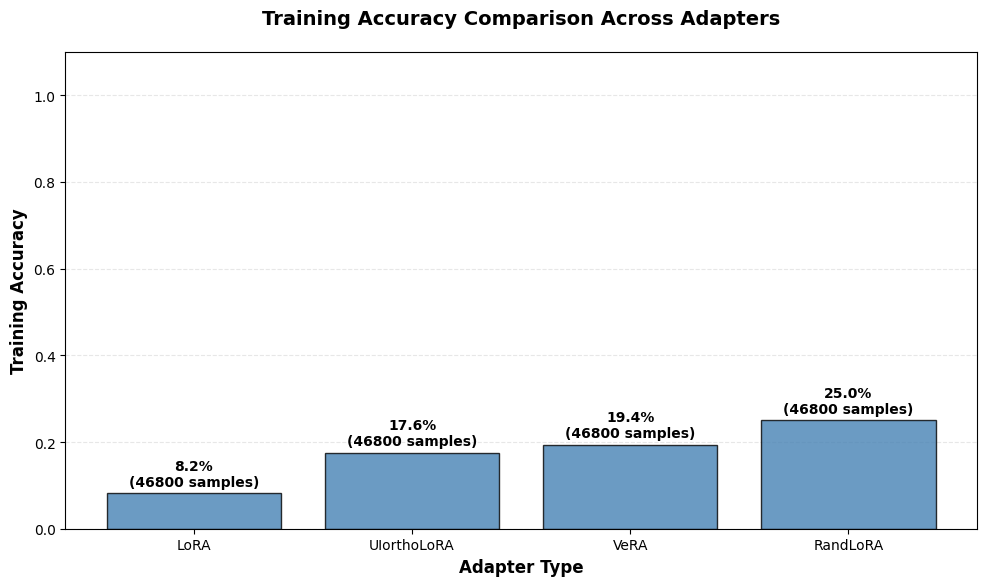

In [16]:
# Plot training accuracy comparison
fig, ax = plot_training_accuracy_comparison(
    all_metrics,
    save_path='training_accuracy_comparison.png'
)
plt.show()

## Visualization: Shift Comparison

Compare positive and negative shifts across adapters.

✓ Saved to shift_comparison.png


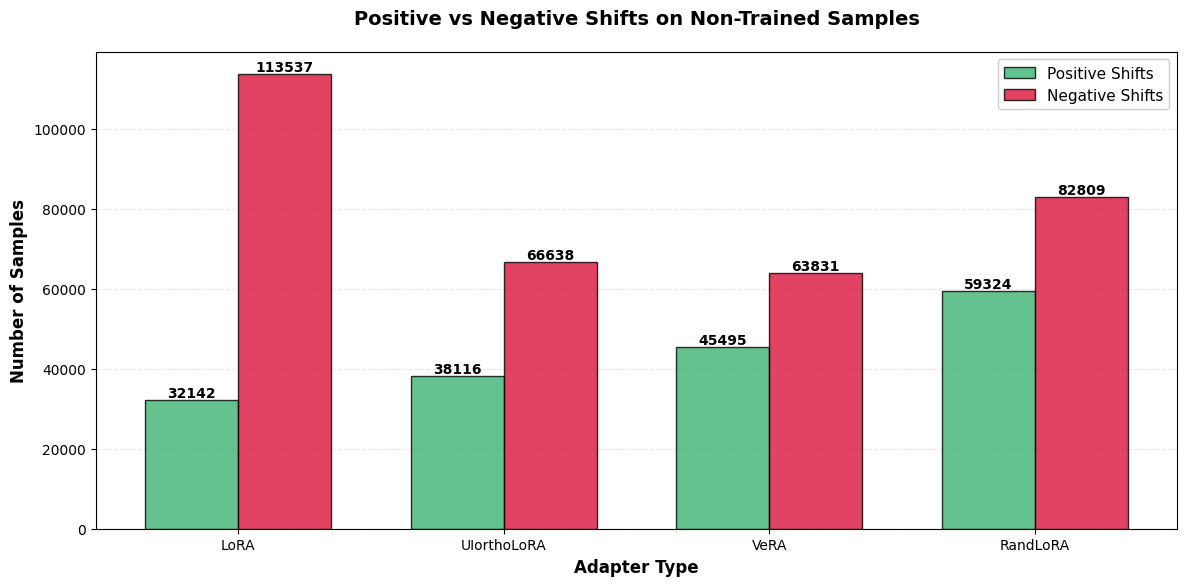

In [17]:
# Plot shift comparison
fig, ax = plot_shift_comparison(
    all_metrics,
    save_path='shift_comparison.png'
)
plt.show()

## Visualization: Knowledge State Transitions

Heatmaps showing how knowledge states change for each adapter.

✓ Saved to knowledge_transitions_lora.png


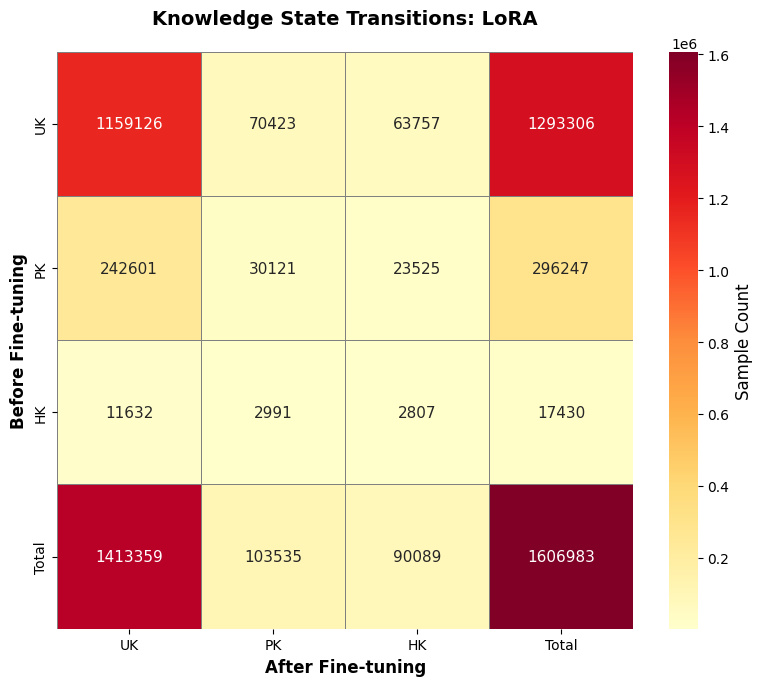

✓ Saved to knowledge_transitions_uiortholora.png


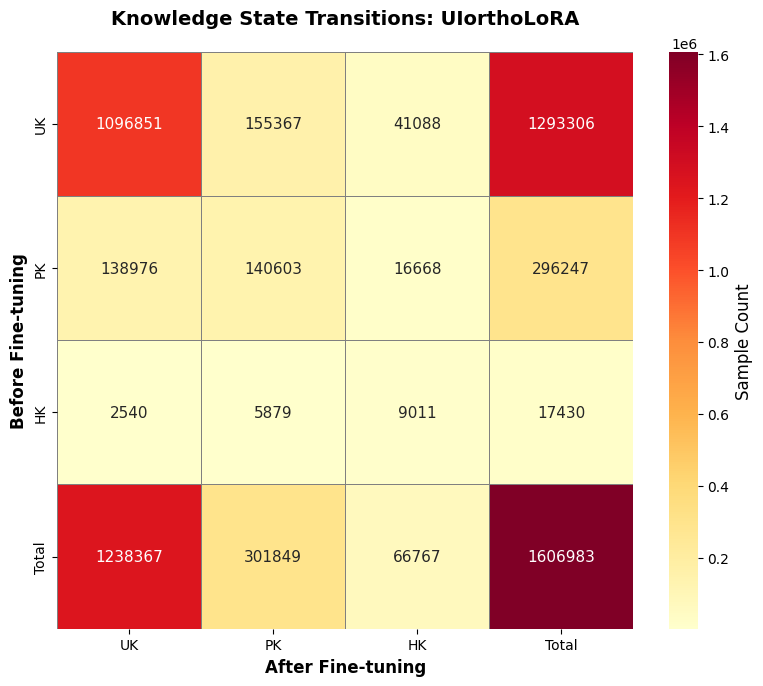

✓ Saved to knowledge_transitions_vera.png


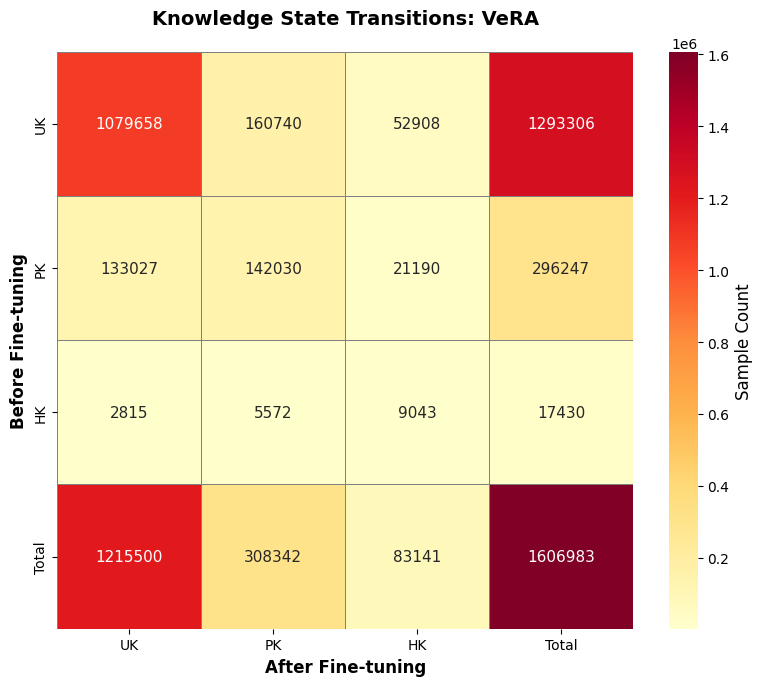

✓ Saved to knowledge_transitions_randlora.png


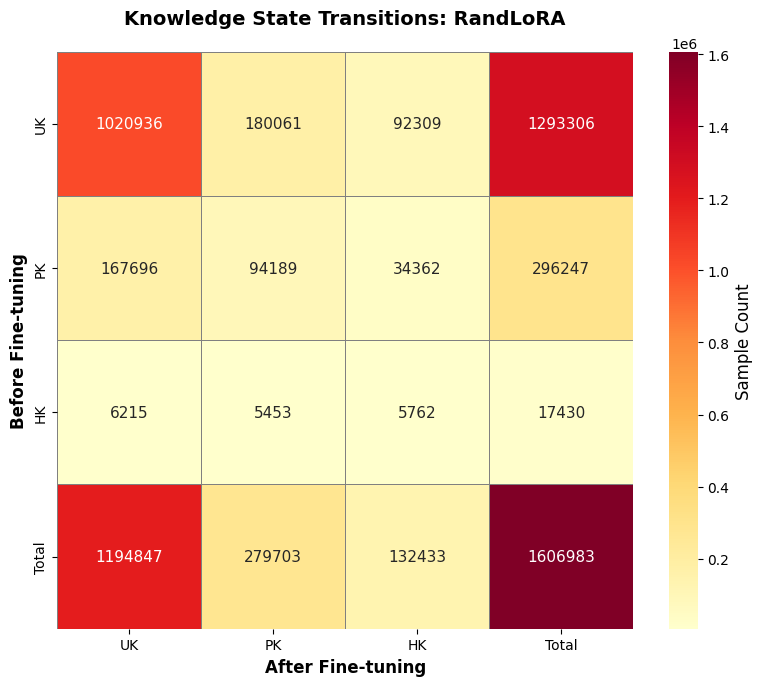

In [18]:
# Plot knowledge transition heatmaps for all adapters
for adapter_name, df in adapter_results.items():
    fig, ax = plot_knowledge_transition_heatmap(
        df,
        adapter_name,
        save_path=f'knowledge_transitions_{adapter_name.lower()}.png'
    )
    plt.show()

## Visualization: Detailed Shift Analysis

Comprehensive shift analysis for each adapter.

/tmp/ipykernel_251998/1834649783.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(shift_data, labels=base_states, patch_artist=True)


✓ Saved to detailed_analysis_lora.png


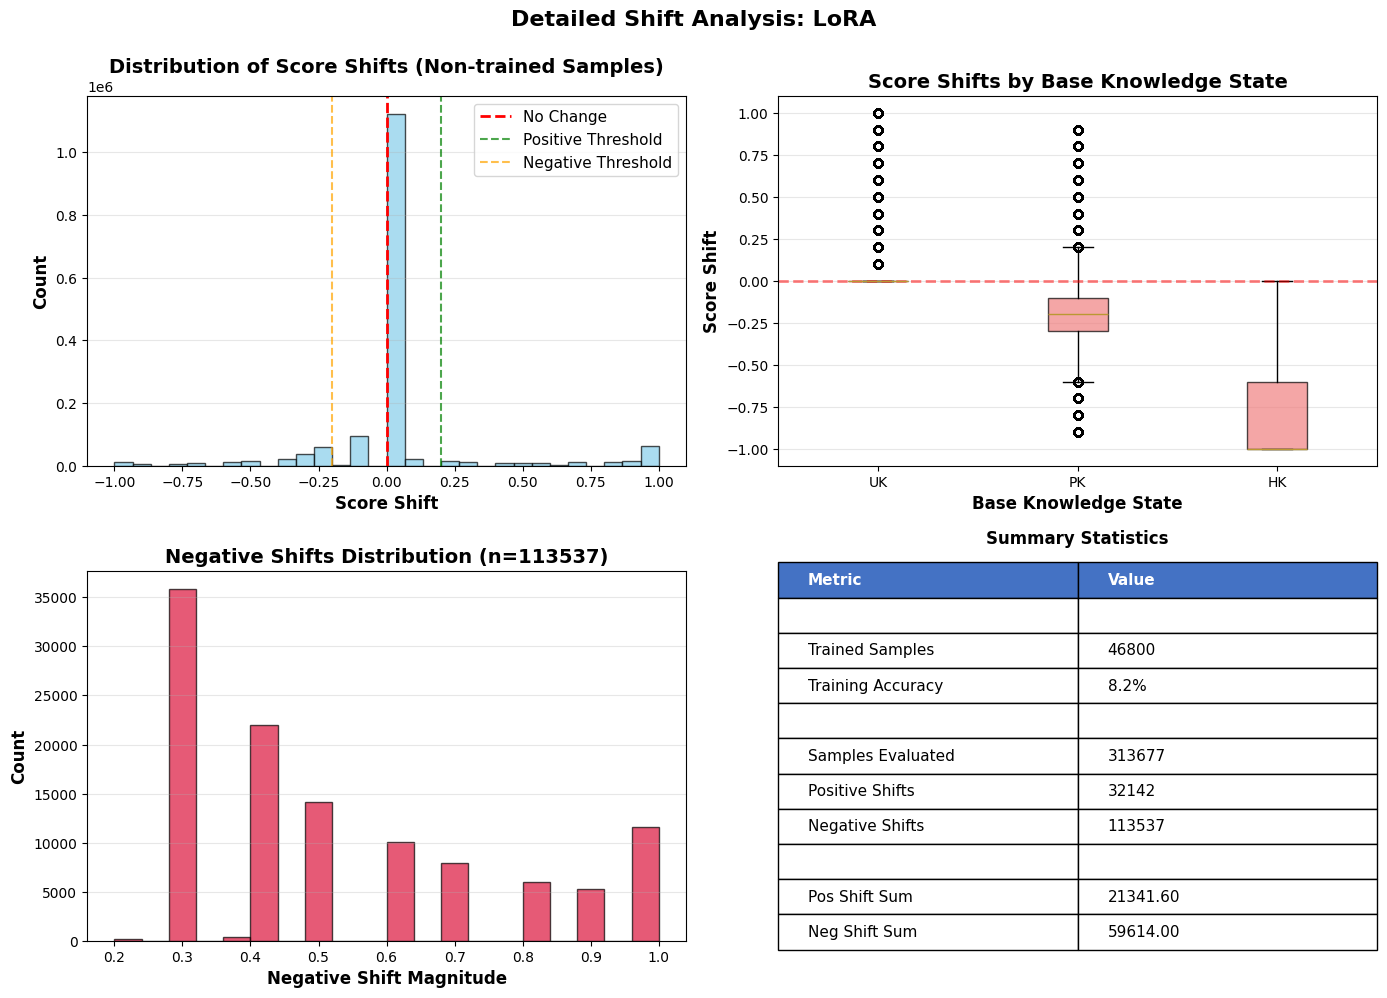

/tmp/ipykernel_251998/1834649783.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(shift_data, labels=base_states, patch_artist=True)


✓ Saved to detailed_analysis_uiortholora.png


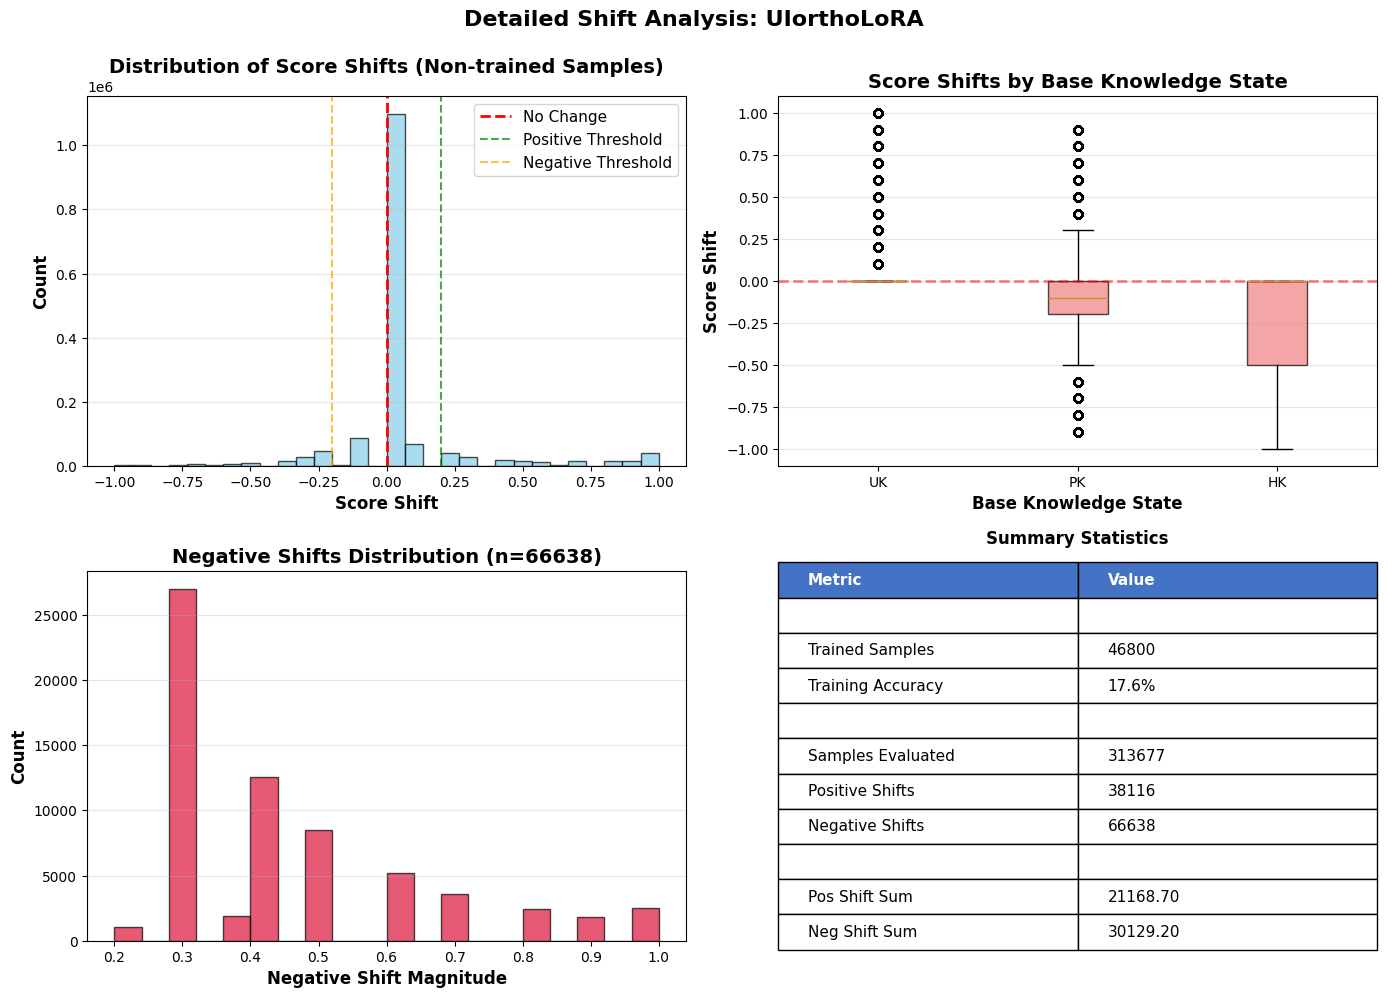

/tmp/ipykernel_251998/1834649783.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(shift_data, labels=base_states, patch_artist=True)


✓ Saved to detailed_analysis_vera.png


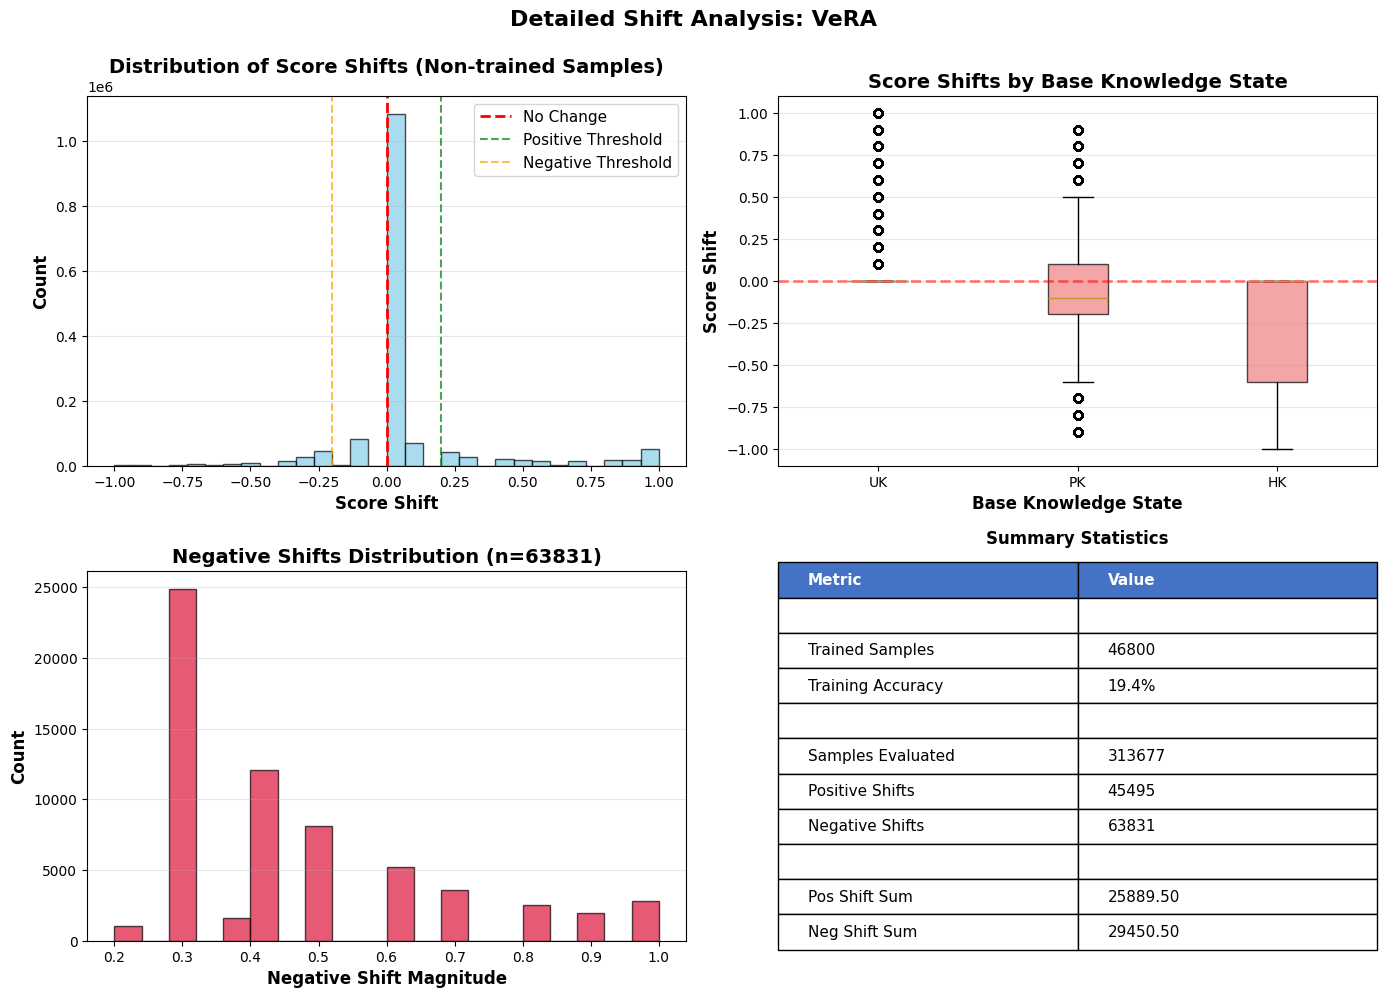

/tmp/ipykernel_251998/1834649783.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(shift_data, labels=base_states, patch_artist=True)


✓ Saved to detailed_analysis_randlora.png


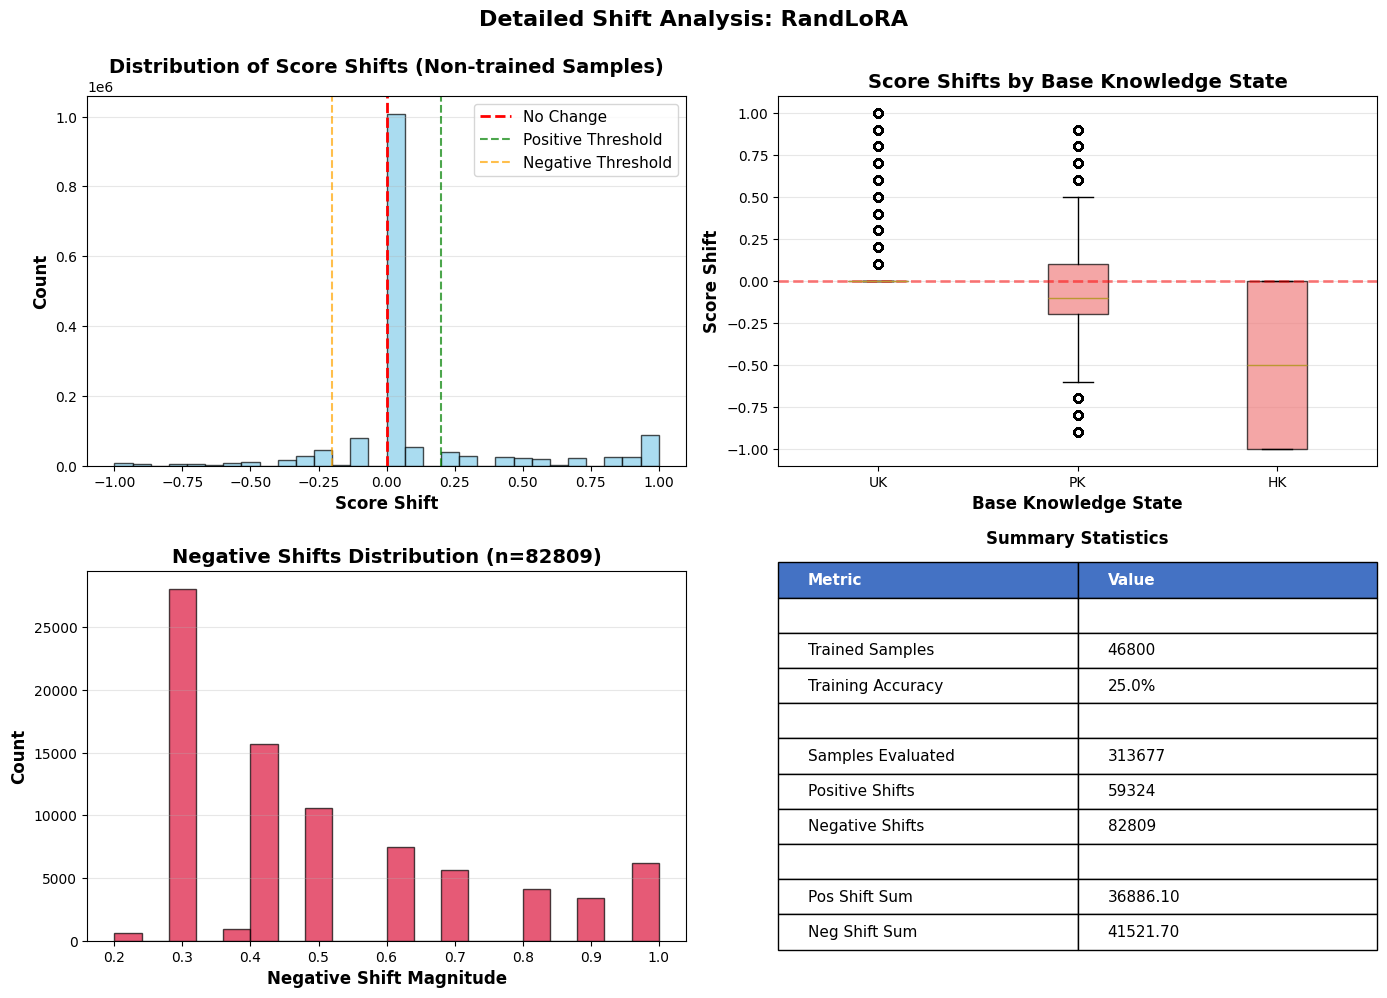

In [19]:
# Plot detailed shift analysis for all adapters
for adapter_name, df in adapter_results.items():
    fig, axes = plot_detailed_shift_analysis(
        df,
        adapter_name,
        save_path=f'detailed_analysis_{adapter_name.lower()}.png'
    )
    plt.show()

## Key Findings Summary

Highlight the most important insights from the analysis.

In [20]:
# Generate key findings
print("\n" + "═" * 100)
print("KEY FINDINGS")
print("═" * 100)

# Best training accuracy
best_acc_adapter = max(all_metrics.items(), key=lambda x: x[1]['training_accuracy'])
print(f"\n🏆 BEST TRAINING ACCURACY: {best_acc_adapter[0]}")
print(f"   Accuracy: {best_acc_adapter[1]['training_accuracy']:.1%}")

# Fewest negative shifts
fewest_neg = min(all_metrics.items(), key=lambda x: x[1]['negative_shift_count'])
print(f"\n✅ FEWEST NEGATIVE SHIFTS: {fewest_neg[0]}")
print(f"   Count: {fewest_neg[1]['negative_shift_count']}")

# Most negative shifts
most_neg = max(all_metrics.items(), key=lambda x: x[1]['negative_shift_count'])
print(f"\n⚠️  MOST NEGATIVE SHIFTS: {most_neg[0]}")
print(f"   Count: {most_neg[1]['negative_shift_count']}")

# Best positive/negative ratio
ratios = {}
for name, metrics in all_metrics.items():
    if metrics['negative_shift_count'] > 0:
        ratios[name] = metrics['positive_shift_count'] / metrics['negative_shift_count']
    else:
        ratios[name] = float('inf')

best_ratio_adapter = max(ratios.items(), key=lambda x: x[1] if x[1] != float('inf') else 0)
print(f"\n📊 BEST POSITIVE/NEGATIVE RATIO: {best_ratio_adapter[0]}")
if best_ratio_adapter[1] != float('inf'):
    print(f"   Ratio: {best_ratio_adapter[1]:.2f}")
else:
    print(f"   No negative shifts!")

print("\n" + "═" * 100)

print("\n✓ Analysis complete! All visualizations have been generated and saved.")


════════════════════════════════════════════════════════════════════════════════════════════════════
KEY FINDINGS
════════════════════════════════════════════════════════════════════════════════════════════════════

🏆 BEST TRAINING ACCURACY: RandLoRA
   Accuracy: 25.0%

✅ FEWEST NEGATIVE SHIFTS: VeRA
   Count: 63831

⚠️  MOST NEGATIVE SHIFTS: LoRA
   Count: 113537

📊 BEST POSITIVE/NEGATIVE RATIO: RandLoRA
   Ratio: 0.72

════════════════════════════════════════════════════════════════════════════════════════════════════

✓ Analysis complete! All visualizations have been generated and saved.


## Summary

This notebook provides a comprehensive analysis of fine-tuned adapter performance on the Llama-3.1-8B model.

**Key Analyses Performed:**

1. **Training Accuracy Assessment**
   - Measured percentage of trained samples that improved
   - Compared across all adapter types

2. **Negative Shift Analysis**
   - Identified samples that performed worse after fine-tuning
   - Quantified magnitude and distribution of negative shifts
   - Highlighted adapters with minimal negative impact

3. **Knowledge State Transitions**
   - Tracked movement between UK, PK, and HK states
   - Visualized transition patterns via heatmaps

4. **Comparative Evaluation**
   - Direct comparison across LoRA, UIorthoLoRA, VeRA, and RandLoRA
   - Identified best-performing adapter for each metric

**Outputs Generated:**
- Comparison table (CSV format)
- Training accuracy bar chart
- Shift comparison visualizations
- Knowledge transition heatmaps
- Detailed shift analysis plots
- Summary statistics and key findings

**Metrics Computed:**
- Training accuracy (% of trained samples with positive scores)
- Negative shift count and sum
- Positive shift count and sum
- Knowledge state transition matrices
- Shift distributions and magnitudes